**Introducción a la Ciencia de Datos 2026**
Posgrado en Ciencias de la Computación - CICESE
Dr. Irvin Hussein López Nava

## ICD - 12: Clasificación

Sesión 12 del curso. Diapositivas: [icd-12-clasificacion.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-12-clasificacion.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-12-clasificacion.ipynb)

En clase vimos cómo se evalúa un clasificador: con datos que no vio, partidos por hold-out, validación cruzada o bootstrap, y medidos con métricas que salen de la matriz de confusión. En la sesión 11 esas métricas tenían dos clases. Aquí pasamos a tres, que es donde aparecen las preguntas difíciles: qué es un falso positivo cuando no hay un solo «positivo», y cómo se resume en un número el desempeño de varias clases.

Usamos el vino tinto de la Tarea 3 con la calidad en tres clases. Primero calculamos a mano las métricas de cada clase y sus promedios, y los comparamos con lo que reportan scikit-learn, Weka y Orange. Después evaluamos varios clasificadores con validación cruzada y vemos cómo los duplicados del vino contaminan la evaluación, como advierte Domingos (2012). El notebook cierra con la curva ROC, que muestra todos los umbrales de la sesión 11 a la vez.

---

### Preparación

Las bibliotecas de siempre. Los clasificadores de la sección 6 vienen de scikit-learn y por ahora son cajas negras; las sesiones 13 a 16 los abren uno por uno.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)

numpy        2.5.3
pandas       3.0.5
matplotlib   3.11.2
scikit-learn 1.9.1


Paleta y estilo de las sesiones anteriores. El naranja sigue siendo lo que produce el modelo.

In [2]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_MEDIO = "#3C51A9"
NARANJA = "#E76A28"      # lo que produce el modelo
GRIS = "#5B6584"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlecolor": AZUL_OSCURO,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": AZUL_OSCURO,
    "axes.edgecolor": "#C9CFDF",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E6EF",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "legend.frameon": False,
})

SEMILLA = 42                        # fija las particiones para que los resultados se repitan
CLASES = ["baja", "media", "alta"]  # el orden en que se muestran las clases

---

### Los datos

Los 1599 vinos tintos de la Tarea 3 (Cortez *et al.*, 2009), con sus once mediciones fisicoquímicas. La calificación de los catadores, de 3 a 8, se agrupó en tres clases: **baja** (3 a 5), **media** (6) y **alta** (7 y 8). La columna original `quality` se quitó: dejarla junto a `calidad` sería darle la respuesta al modelo.

El archivo está en `datos/`, junto con su versión en ARFF para Weka:

- **En tu máquina.** La primera línea funciona tal cual desde la carpeta del repositorio clonado.
- **En Colab.** Comenta la primera línea y descomenta la segunda.

In [3]:
vinos = pd.read_csv("datos/vinos-3clases.csv")
# vinos = pd.read_csv("https://raw.githubusercontent.com/husseinlopez/icd2026/main/datos/vinos-3clases.csv")

X = vinos.drop(columns="calidad")
y = vinos["calidad"]

print(f"{X.shape[0]} vinos × {X.shape[1]} variables")
y.value_counts().reindex(CLASES).to_frame("vinos").assign(proporción=lambda t: (t["vinos"] / len(y)).round(3))

1599 vinos × 11 variables


,vinos,proporción
calidad,,
baja,744,0.465
media,638,0.399
alta,217,0.136


**Lectura.** Las clases no están balanceadas: casi la mitad de los vinos es de calidad baja y solo 14 % es de calidad alta. Un clasificador que siempre diga «baja» ya acierta 46.5 %, y ese es el número que cualquier modelo tiene que superar.

---

## 1. Partición estratificada y línea base

Apartamos 20 % para prueba, como en la sesión 10, pero ahora **estratificado**: `stratify=y` hace que cada clase conserve su proporción en las dos partes. Con 217 vinos de calidad alta, un sorteo sin estratificar podría dejar en prueba bastantes menos de los que le tocan.

In [4]:
from sklearn.model_selection import train_test_split

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEMILLA)

pd.DataFrame({
    "todos": y.value_counts(normalize=True),
    "entrenamiento": y_entrena.value_counts(normalize=True),
    "prueba": y_prueba.value_counts(normalize=True),
}).reindex(CLASES).round(3)

,todos,entrenamiento,prueba
calidad,,,
baja,0.465,0.465,0.466
media,0.399,0.399,0.400
alta,0.136,0.136,0.134


Las tres columnas casi coinciden. En prueba quedan 149 vinos de calidad baja, 128 de media y 43 de alta.

La **línea base** es el clasificador que ignora las variables y predice siempre la clase más frecuente del entrenamiento. En scikit-learn es `DummyClassifier`; en Weka, ZeroR, y en Orange, Constant.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

base = DummyClassifier(strategy="most_frequent").fit(X_entrena, y_entrena)
pred_base = base.predict(X_prueba)

print(f"Siempre predice: {pred_base[0]}")
print(f"Exactitud: {accuracy_score(y_prueba, pred_base):.3f}")
print(f"F1 macro:  {f1_score(y_prueba, pred_base, labels=CLASES, average='macro', zero_division=0):.3f}")

Siempre predice: baja
Exactitud: 0.466
F1 macro:  0.212


**Lectura.** La línea base acierta 46.6 % sin mirar un solo vino. Su F1 macro, en cambio, es 0.212: nunca detecta un vino de calidad media ni de calidad alta, y el promedio macro le da a esas dos clases el mismo peso que a la mayoritaria. La sección 4 explica de dónde sale ese número.

---

## 2. La matriz de confusión con tres clases

El clasificador es la regresión logística de la sesión 11. Con tres clases, scikit-learn usa la versión multinomial: estima tres probabilidades, una por clase, que suman 1, y predice la de mayor probabilidad. Como en la sesión 11, `C=np.inf` quita la regularización, y el escalado va dentro del `Pipeline`, así que solo aprende la media y la desviación estándar del entrenamiento.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

logistica = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000))
logistica.fit(X_entrena, y_entrena)
pred = logistica.predict(X_prueba)

probas = pd.DataFrame(logistica.predict_proba(X_prueba), columns=logistica.classes_)[CLASES]
probas.assign(predicción=pred[:len(probas)], real=y_prueba.to_numpy()).head(4).round(3)

,baja,media,alta,predicción,real
0,0.651,0.335,0.013,baja,media
1,0.763,0.230,0.006,baja,baja
2,0.678,0.304,0.018,baja,baja
3,0.884,0.113,0.003,baja,baja


Cada fila suma 1 y la predicción es la columna con la probabilidad más alta. La matriz de confusión cuenta, para cada clase real (filas), cuántos vinos se predijeron en cada clase (columnas). El argumento `labels` fija el orden; sin él, scikit-learn ordena las clases alfabéticamente.

In [7]:
from sklearn.metrics import confusion_matrix

matriz = confusion_matrix(y_prueba, pred, labels=CLASES)
pd.DataFrame(matriz, index=[f"real: {c}" for c in CLASES], columns=[f"predicha: {c}" for c in CLASES])

,predicha: baja,predicha: media,predicha: alta
real: baja,112,36,1
real: media,51,64,13
real: alta,3,25,15


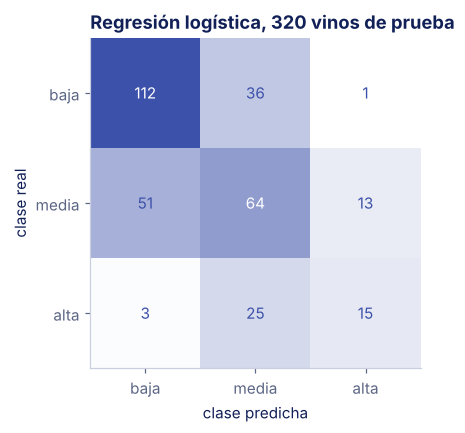

In [8]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import ConfusionMatrixDisplay

azules = LinearSegmentedColormap.from_list("azules", ["#FFFFFF", AZUL_MEDIO])

fig, ax = plt.subplots(figsize=(4.6, 3.9))
ConfusionMatrixDisplay(matriz, display_labels=CLASES).plot(ax=ax, cmap=azules, colorbar=False)
ax.grid(False)
ax.set_xlabel("clase predicha")
ax.set_ylabel("clase real")
ax.set_title("Regresión logística, 320 vinos de prueba")
plt.show()

La exactitud es la diagonal entre el total:

In [9]:
aciertos = np.trace(matriz)
n = matriz.sum()
print(f"Aciertos: {aciertos} de {n}")
print(f"Exactitud a mano:    {aciertos / n:.3f}")
print(f"Exactitud (sklearn): {accuracy_score(y_prueba, pred):.3f}")

Aciertos: 191 de 320
Exactitud a mano:    0.597
Exactitud (sklearn): 0.597


**Lectura.** La logística acierta 191 de 320 vinos (0.597), contra 0.466 de la línea base. La matriz dice además *en qué* se equivoca: casi todos los errores son entre clases vecinas. Solo un vino de calidad baja se predijo como alta, y solo tres de calidad alta como baja. La clase alta es la que peor le va: de sus 43 vinos, el modelo reconoce 15 y manda 25 a «media».

---

## 3. Uno contra el resto

Con dos clases había un positivo y un negativo. Con tres, cada clase se vuelve el positivo por turnos, y las otras dos juntas son el negativo (láminas 31 y 32). Para la clase $k$, con $C$ la matriz de confusión:

- **TP**: su celda de la diagonal, $C_{kk}$.
- **FN**: el resto de su fila, vinos de la clase $k$ que se predijeron en otra.
- **FP**: el resto de su columna, vinos de otras clases que se predijeron como $k$.
- **TN**: todo lo demás.

En código, sumando filas y columnas:

In [10]:
filas = []
for k, clase in enumerate(CLASES):
    tp = matriz[k, k]
    fn = matriz[k, :].sum() - tp          # resto de su fila
    fp = matriz[:, k].sum() - tp          # resto de su columna
    tn = n - tp - fn - fp                 # todo lo demás
    filas.append({"clase": clase, "TP": tp, "FN": fn, "FP": fp, "TN": tn})

conteos = pd.DataFrame(filas).set_index("clase")
conteos

,TP,FN,FP,TN
clase,,,,
baja,112,37,54,117
media,64,64,61,131
alta,15,28,14,263


scikit-learn hace lo mismo con `multilabel_confusion_matrix`: devuelve una matriz de 2 × 2 por clase. Cuidado con el orden de sus celdas, que es `[[TN, FP], [FN, TP]]`: el negativo va primero.

In [11]:
from sklearn.metrics import multilabel_confusion_matrix

for clase, m in zip(CLASES, multilabel_confusion_matrix(y_prueba, pred, labels=CLASES)):
    print(f"{clase}:  TN = {m[0, 0]:3d}   FP = {m[0, 1]:3d}   FN = {m[1, 0]:3d}   TP = {m[1, 1]:3d}")

baja:  TN = 117   FP =  54   FN =  37   TP = 112
media:  TN = 131   FP =  61   FN =  64   TP =  64
alta:  TN = 263   FP =  14   FN =  28   TP =  15


Coinciden. Con los cuatro conteos de cada clase, las métricas son las del caso binario (lámina 30):

In [12]:
metricas = pd.DataFrame({
    "soporte": conteos["TP"] + conteos["FN"],
    "precisión": conteos["TP"] / (conteos["TP"] + conteos["FP"]),
    "sensibilidad": conteos["TP"] / (conteos["TP"] + conteos["FN"]),
    "especificidad": conteos["TN"] / (conteos["TN"] + conteos["FP"]),
})
metricas["F1"] = 2 * metricas["precisión"] * metricas["sensibilidad"] / (metricas["precisión"] + metricas["sensibilidad"])
metricas.round(3)

,soporte,precisión,sensibilidad,especificidad,F1
clase,,,,,
baja,149,0.675,0.752,0.684,0.711
media,128,0.512,0.500,0.682,0.506
alta,43,0.517,0.349,0.949,0.417


Y la comprobación con scikit-learn, que no calcula la especificidad:

In [13]:
from sklearn.metrics import precision_recall_fscore_support

precision, sensibilidad, f1, soporte = precision_recall_fscore_support(y_prueba, pred, labels=CLASES)
pd.DataFrame({"soporte": soporte, "precisión": precision, "sensibilidad": sensibilidad, "F1": f1},
             index=CLASES).round(3)

,soporte,precisión,sensibilidad,F1
baja,149,0.675,0.752,0.711
media,128,0.512,0.500,0.506
alta,43,0.517,0.349,0.417


**Lectura.** Cada clase tiene su propio desempeño, y el de la clase alta es el más bajo: su sensibilidad es 0.349 (detecta 15 de 43) y su F1, 0.417. Su especificidad, en cambio, es la más alta (0.949), porque el modelo casi nunca predice «alta»: de 277 vinos que no lo son, solo 14 se marcan como alta. Las dos métricas miden cosas distintas, y por eso conviene reportarlas juntas.

---

## 4. Promedios: macro, ponderado y micro

Para comparar clasificadores conviene un solo número. Hay tres maneras de resumir las métricas por clase (lámina 34):

- **Macro.** El promedio simple: las tres clases pesan igual, tengan 149 vinos o 43.
- **Ponderado.** Cada clase pesa según su soporte $n_k / n$, es decir, según cuántos vinos tiene.
- **Micro.** Se suman los TP, FP y FN de todas las clases y después se divide, como si fuera un solo problema.

A mano, con la tabla de la sección 3:

In [14]:
peso = metricas["soporte"] / metricas["soporte"].sum()

tp, fp, fn = conteos["TP"].sum(), conteos["FP"].sum(), conteos["FN"].sum()
precision_micro = tp / (tp + fp)
sensibilidad_micro = tp / (tp + fn)

promedios = pd.DataFrame({
    "macro": metricas[["precisión", "sensibilidad", "F1"]].mean(),
    "ponderado": metricas[["precisión", "sensibilidad", "F1"]].mul(peso, axis=0).sum(),
    "micro": [precision_micro, sensibilidad_micro,
              2 * precision_micro * sensibilidad_micro / (precision_micro + sensibilidad_micro)],
})
promedios.round(3)

,macro,ponderado,micro
precisión,0.568,0.588,0.597
sensibilidad,0.534,0.597,0.597
F1,0.545,0.589,0.597


Las tres versiones con scikit-learn, más dos equivalencias que vale la pena comprobar: el micro es la exactitud, y la sensibilidad macro es la **exactitud balanceada**.

In [15]:
from sklearn.metrics import balanced_accuracy_score

for promedio in ["macro", "weighted", "micro"]:
    print(f"F1 {promedio:<9} {f1_score(y_prueba, pred, labels=CLASES, average=promedio):.3f}")
print()
print(f"Exactitud:             {accuracy_score(y_prueba, pred):.3f}")
print(f"Exactitud balanceada:  {balanced_accuracy_score(y_prueba, pred):.3f}")

F1 macro     0.545
F1 weighted  0.589
F1 micro     0.597

Exactitud:             0.597
Exactitud balanceada:  0.534


`classification_report` reúne todo: las métricas de cada clase, la exactitud y los promedios macro (`macro avg`) y ponderado (`weighted avg`).

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_prueba, pred, labels=CLASES, digits=3))

              precision    recall  f1-score   support

        baja      0.675     0.752     0.711       149
       media      0.512     0.500     0.506       128
        alta      0.517     0.349     0.417        43

    accuracy                          0.597       320
   macro avg      0.568     0.534     0.545       320
weighted avg      0.588     0.597     0.589       320



**Lectura.** El F1 macro es 0.545, el ponderado 0.589 y el micro 0.597. La diferencia viene de la clase alta. El macro la pesa como un tercio del resultado, así que su F1 de 0.417 lo jala hacia abajo. El ponderado la pesa como 43 de 320 vinos, y el micro la mezcla con las otras dos antes de dividir.

¿Cuál reportar? Depende de la pregunta. Si importa detectar todas las clases, incluida la minoritaria, el macro. Si importa el desempeño sobre la mezcla real de vinos, el ponderado o la exactitud. En cualquier caso conviene acompañarlo de las métricas por clase: un solo número esconde justo lo que la tabla de la sección 3 muestra.

---

## 5. Lo que reportan Weka y Orange

Las dos herramientas calculan las mismas métricas por clase, pero el resumen que muestran no es el macro (lámina 35).

**Weka** imprime, en «Detailed Accuracy By Class», una fila por clase y un renglón final, «Weighted Avg.», que pondera cada columna por el número de casos de cada clase. No muestra el macro. Tampoco la especificidad, pero sí la tasa de falsos positivos, FP Rate, que es 1 − especificidad. Su ROC Area es el AUC de cada clase contra el resto, que veremos en la sección 7.

Podemos armar esa misma tabla con nuestras predicciones de prueba:

In [17]:
from sklearn.metrics import roc_auc_score

proba = logistica.predict_proba(X_prueba)
columna = {c: list(logistica.classes_).index(c) for c in CLASES}
auc_clase = {c: roc_auc_score(y_prueba == c, proba[:, columna[c]]) for c in CLASES}

estilo_weka = pd.DataFrame({
    "TP Rate": metricas["sensibilidad"],
    "FP Rate": 1 - metricas["especificidad"],
    "Precision": metricas["precisión"],
    "Recall": metricas["sensibilidad"],
    "F-Measure": metricas["F1"],
    "ROC Area": pd.Series(auc_clase),
})
estilo_weka.loc["Weighted Avg."] = estilo_weka.mul(peso, axis=0).sum()
estilo_weka.round(3)

,TP Rate,FP Rate,Precision,Recall,F-Measure,ROC Area
baja,0.752,0.316,0.675,0.752,0.711,0.818
media,0.500,0.318,0.512,0.500,0.506,0.661
alta,0.349,0.051,0.517,0.349,0.417,0.860
Weighted Avg.,0.597,0.281,0.588,0.597,0.589,0.761


El renglón «Weighted Avg.» coincide con el `weighted avg` de `classification_report`. Para el macro hay que promediar la columna de las tres clases:

In [18]:
print(f"F-Measure, Weighted Avg. (lo que muestra Weka): {estilo_weka.loc['Weighted Avg.', 'F-Measure']:.3f}")
print(f"F-Measure macro (promedio de la columna):       {estilo_weka.loc[CLASES, 'F-Measure'].mean():.3f}")

F-Measure, Weighted Avg. (lo que muestra Weka): 0.589
F-Measure macro (promedio de la columna):       0.545


En la demo, Weka evalúa con validación cruzada de 10 pliegues sobre los 1599 vinos, así que sus cifras no coinciden con las de esta partición. El promedio sí funciona igual. Esta es la salida de J48, el árbol de decisión de la sesión 13:

```
=== Detailed Accuracy By Class ===

                 TP Rate  FP Rate  Precision  Recall   F-Measure  MCC      ROC Area  PRC Area  Class
                 0.754    0.247    0.727      0.754    0.740      0.506    0.782     0.701     baja
                 0.597    0.249    0.615      0.597    0.606      0.350    0.685     0.566     media
                 0.553    0.063    0.580      0.553    0.566      0.500    0.808     0.474     alta
Weighted Avg.    0.664    0.223    0.662      0.664    0.663      0.443    0.747     0.616
```

El F1 macro de J48 es (0.740 + 0.606 + 0.566) / 3 = 0.637, y no aparece en la salida; Weka reporta el ponderado, 0.663.

**Orange** muestra en Test and Score una fila por modelo. Con la opción «(None, show average over classes)», F1, Prec, Recall y Spec son promedios ponderados por soporte. El AUC usa otro peso para cada clase, $n_k (n - n_k)$, el número de parejas (positivo, negativo) que la curva de esa clase compara. Al elegir una clase en «Target class», las métricas son las de esa clase contra el resto.

Los tres promedios del AUC con nuestras predicciones:

In [19]:
soporte_clase = metricas["soporte"]
peso_orange = soporte_clase * (n - soporte_clase)
peso_orange = peso_orange / peso_orange.sum()
auc = pd.Series(auc_clase)

print(f"AUC por clase:  " + "   ".join(f"{c} {auc[c]:.3f}" for c in CLASES))
print(f"Macro:                        {auc.mean():.3f}")
print(f"Ponderado por soporte (Weka): {(auc * peso).sum():.3f}")
print(f"Ponderado como Orange:        {(auc * peso_orange).sum():.3f}")

AUC por clase:  baja 0.818   media 0.661   alta 0.860
Macro:                        0.780
Ponderado por soporte (Weka): 0.761
Ponderado como Orange:        0.764


**Lectura.** Las tres herramientas coinciden en las métricas de cada clase y difieren en cómo las resumen. La regla práctica: antes de comparar un número entre herramientas o entre artículos, averiguar qué promedio es.

### El formato ARFF

Weka lee su propio formato, ARFF: un encabezado declara cada atributo y su tipo, y la clase nominal lleva la lista de sus valores. Así se generó `datos/vinos-3clases.arff` a partir del CSV:

In [20]:
def a_arff(tabla, clase, relacion):
    # Devuelve el texto ARFF de una tabla con atributos numéricos y una clase nominal (al final).
    lineas = [f"@relation {relacion}", ""]
    for col in tabla.columns.drop(clase):
        lineas.append(f"@attribute '{col}' numeric")
    valores = ",".join(CLASES)                     # el orden de la clase nominal
    lineas += [f"@attribute {clase} {{{valores}}}", "", "@data"]
    for fila in tabla.itertuples(index=False):
        lineas.append(",".join(str(v) for v in fila))
    return "\n".join(lineas) + "\n"


texto = a_arff(vinos, "calidad", "vinos-3clases")
print("\n".join(texto.splitlines()[:16]))

@relation vinos-3clases

@attribute 'fixed acidity' numeric
@attribute 'volatile acidity' numeric
@attribute 'citric acid' numeric
@attribute 'residual sugar' numeric
@attribute 'chlorides' numeric
@attribute 'free sulfur dioxide' numeric
@attribute 'total sulfur dioxide' numeric
@attribute 'density' numeric
@attribute 'pH' numeric
@attribute 'sulphates' numeric
@attribute 'alcohol' numeric
@attribute calidad {baja,media,alta}

@data


La clase va al final porque Weka toma, por omisión, el último atributo como clase. Orange lee el CSV directamente; ahí la clase se elige en el widget File, con el rol *target*.

---

## 6. Validación cruzada: varios clasificadores

Una sola partición de 320 vinos da un solo número, y la sesión 10 mostró cuánto puede variar con otro sorteo. La validación cruzada de 10 pliegues usa cada vino como prueba exactamente una vez y da 10 estimaciones, una por pliegue (lámina 23). `StratifiedKFold` mantiene la proporción de clases en cada pliegue, y `cross_validate` calcula varias métricas a la vez.

Comparamos la línea base, la logística y cuatro clasificadores que se verán en las próximas sesiones: Naive Bayes, un árbol de decisión, el vecino más cercano (k = 1) y una SVM. Los que dependen de distancias llevan el escalado dentro del `Pipeline`, para que cada pliegue lo aprenda solo de su entrenamiento.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

modelos = {
    "línea base": DummyClassifier(strategy="most_frequent"),
    "regresión logística": make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000)),
    "Naive Bayes": GaussianNB(),
    "árbol de decisión": DecisionTreeClassifier(random_state=0),
    "1 vecino": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)),
    "SVM": make_pipeline(StandardScaler(), SVC()),
}

pliegues = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEMILLA)
metricas_cv = ["accuracy", "f1_macro", "f1_weighted"]

resultados = {}
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X, y, cv=pliegues, scoring=metricas_cv)
    resultados[nombre] = r

tabla_cv = pd.DataFrame({
    nombre: {"exactitud": r["test_accuracy"].mean(),
             "F1 macro": r["test_f1_macro"].mean(),
             "desv. est. F1 macro": r["test_f1_macro"].std(),
             "F1 ponderado": r["test_f1_weighted"].mean()}
    for nombre, r in resultados.items()}).T
tabla_cv.sort_values("F1 macro", ascending=False).round(3)

,exactitud,F1 macro,desv. est. F1 macro,F1 ponderado
1 vecino,0.689,0.671,0.030,0.689
árbol de decisión,0.673,0.649,0.043,0.674
SVM,0.654,0.594,0.040,0.645
Naive Bayes,0.605,0.578,0.045,0.605
regresión logística,0.631,0.574,0.039,0.624
línea base,0.465,0.212,0.001,0.296


Los 10 valores de F1 macro de cada modelo, uno por pliegue:

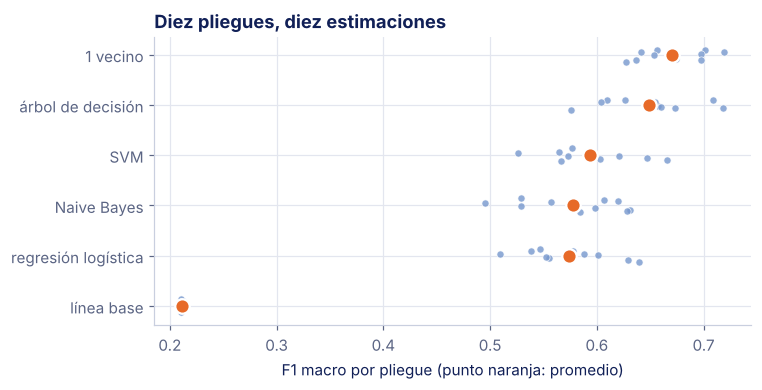

In [22]:
orden = tabla_cv.sort_values("F1 macro").index
rng = np.random.default_rng(SEMILLA)

fig, ax = plt.subplots(figsize=(7, 3.4))
for fila, nombre in enumerate(orden):
    valores = resultados[nombre]["test_f1_macro"]
    ax.scatter(valores, fila + rng.uniform(-0.15, 0.15, len(valores)), s=22, color=AZUL, alpha=0.8,
               edgecolor="white", linewidth=0.5)
    ax.scatter(valores.mean(), fila, s=90, color=NARANJA, edgecolor="white", linewidth=1.5, zorder=3)
ax.set_yticks(range(len(orden)), orden)
ax.set_xlabel("F1 macro por pliegue (punto naranja: promedio)")
ax.set_title("Diez pliegues, diez estimaciones")
plt.show()

**Lectura.** Con la partición usual, el vecino más cercano y el árbol quedan arriba (F1 macro de 0.67 y 0.65), y la logística, Naive Bayes y la SVM entre 0.57 y 0.59. Pero las nubes de puntos se enciman: la desviación estándar entre pliegues es de 0.03 a 0.05, del mismo tamaño que las diferencias entre la logística, Naive Bayes y la SVM. Con estos datos, esos tres no se distinguen entre sí.

¿Y el primer lugar? Tiene truco.

### La contaminación por duplicados

El vino trae filas repetidas desde la fuente:

In [23]:
gemelas = vinos.duplicated(keep=False)
print(f"Filas duplicadas (copias extra): {vinos.duplicated().sum()}")
print(f"Vinos con al menos una gemela:   {gemelas.sum()} de {len(vinos)}")

Filas duplicadas (copias extra): 240
Vinos con al menos una gemela:   460 de 1599


En la validación cruzada usual, una copia puede caer en entrenamiento y su gemela en prueba. El vecino más cercano encuentra en entrenamiento un vino idéntico y le copia la clase; el árbol, que crece hasta separar casi cada vino, hace algo parecido. Es la contaminación «insidiosa» de Domingos (2012): nadie usó la prueba para entrenar, y aun así la prueba se filtró.

Para medirlo, repetimos la evaluación con `StratifiedGroupKFold`, que recibe un grupo por fila y nunca separa un grupo entre entrenamiento y prueba. El grupo de cada fila es su contenido completo, así que las gemelas comparten grupo.

In [24]:
from sklearn.model_selection import StratifiedGroupKFold

grupos = pd.util.hash_pandas_object(vinos, index=False)   # filas idénticas, mismo grupo
pliegues_grupo = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEMILLA)

comparacion = {}
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X, y, cv=pliegues_grupo, groups=grupos, scoring=["f1_macro"])
    comparacion[nombre] = {"partición usual": resultados[nombre]["test_f1_macro"].mean(),
                           "gemelas juntas": r["test_f1_macro"].mean()}

comparacion = pd.DataFrame(comparacion).T
comparacion["cambio"] = comparacion["gemelas juntas"] - comparacion["partición usual"]
comparacion.sort_values("partición usual", ascending=False).round(3)

,partición usual,gemelas juntas,cambio
1 vecino,0.671,0.545,-0.125
árbol de decisión,0.649,0.526,-0.123
SVM,0.594,0.600,0.006
Naive Bayes,0.578,0.577,-0.001
regresión logística,0.574,0.574,0.001
línea base,0.212,0.212,0.000


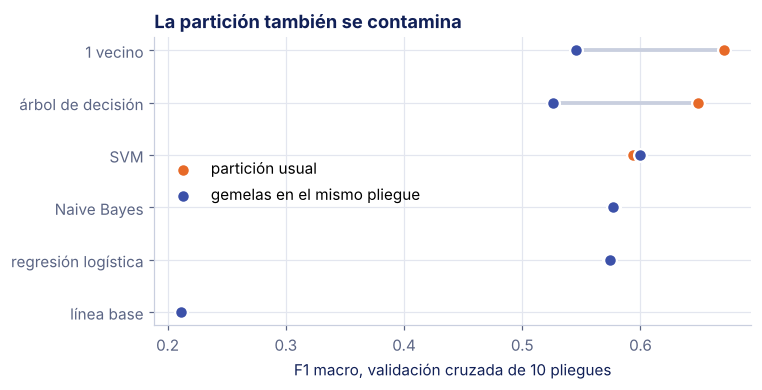

In [25]:
orden = comparacion.sort_values("partición usual").index
fig, ax = plt.subplots(figsize=(7, 3.4))
for fila, nombre in enumerate(orden):
    a, b = comparacion.loc[nombre, ["partición usual", "gemelas juntas"]]
    ax.plot([a, b], [fila, fila], color="#C9CFDF", linewidth=2.5, zorder=1)
ax.scatter(comparacion.loc[orden, "partición usual"], range(len(orden)), s=70, color=NARANJA,
           edgecolor="white", linewidth=1.5, zorder=3, label="partición usual")
ax.scatter(comparacion.loc[orden, "gemelas juntas"], range(len(orden)), s=70, color=AZUL_MEDIO,
           edgecolor="white", linewidth=1.5, zorder=3, label="gemelas en el mismo pliegue")
ax.set_yticks(range(len(orden)), orden)
ax.set_xlabel("F1 macro, validación cruzada de 10 pliegues")
ax.set_title("La partición también se contamina")
ax.legend(loc="center left")
plt.show()

**Lectura.** Con las gemelas en el mismo pliegue, el vecino más cercano baja de 0.67 a 0.55 y el árbol de 0.65 a 0.53: pasan de los primeros lugares a los últimos. La logística, Naive Bayes y la SVM casi no se mueven, porque no memorizan casos. Es la lámina 27. El primer lugar de la tabla anterior no medía qué tan bien generaliza el modelo, sino qué tan bien reconoce vinos que ya había visto.

Weka y Orange no saben que hay duplicados y usan la partición usual. En la demo, IBk con un solo vecino sale primero en Weka, con 69.3 % de aciertos, y el árbol en Orange. Por eso la revisión de duplicados de la sesión 5 no es un trámite: decide qué modelo parece el mejor.

---

## 7. Todos los umbrales a la vez: la curva ROC

La sesión 11 terminó moviendo el umbral de la logística que predice la progresión alta de la diabetes con el IMC: cada umbral daba otra sensibilidad y otra especificidad. La **curva ROC** muestra todos los umbrales a la vez (lámina 40). Reconstruimos ese modelo con la misma partición:

In [26]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import roc_curve

diabetes = load_diabetes(as_frame=True, scaled=False)
tabla = diabetes.data.assign(alta=(diabetes.target >= 200).astype(int))
entrena, prueba = train_test_split(tabla, test_size=0.2, random_state=SEMILLA)

curva = LogisticRegression(C=np.inf).fit(entrena[["bmi"]], entrena["alta"])
p = curva.predict_proba(prueba[["bmi"]])[:, 1]
real = prueba["alta"].to_numpy()

fpr, tpr, umbrales = roc_curve(real, p)
print(f"{len(umbrales)} umbrales distintos para {len(real)} pacientes de prueba")

42 umbrales distintos para 89 pacientes de prueba


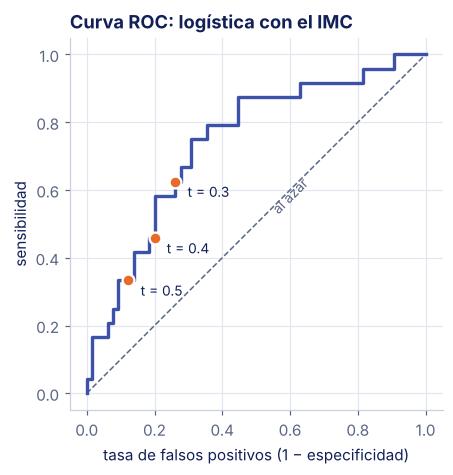

In [27]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], color=GRIS, linewidth=1, linestyle="--")
ax.plot(fpr, tpr, color=AZUL_MEDIO, linewidth=2.2, drawstyle="steps-post")
for t in [0.5, 0.4, 0.3]:
    vn, fp_, fn_, vp = confusion_matrix(real, (p >= t).astype(int)).ravel()
    x_, y_ = fp_ / (fp_ + vn), vp / (vp + fn_)
    ax.scatter(x_, y_, s=60, color=NARANJA, edgecolor="white", linewidth=1.5, zorder=3)
    ax.annotate(f"t = {t}", (x_, y_), xytext=(8, -10), textcoords="offset points", color=AZUL_OSCURO, fontsize=9)
ax.text(0.6, 0.53, "al azar", color=GRIS, fontsize=9, rotation=45, ha="center")
ax.set_xlabel("tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("sensibilidad")
ax.set_title("Curva ROC: logística con el IMC")
ax.set_aspect("equal")
plt.show()

**Lectura.** Cada escalón es un umbral. Los tres puntos son los de la sesión 11: con 0.5, la sensibilidad es 0.33 con 12 % de falsos positivos; con 0.3, sube a 0.62 a cambio de 26 %. La diagonal es lo que haría un clasificador que decide al azar.

El **área bajo la curva** resume la curva entera en un número, y tiene una lectura directa: es la probabilidad de que un paciente con progresión alta, tomado al azar, reciba mayor probabilidad que uno sin ella (lámina 41). Lo comprobamos contando todas las parejas:

In [28]:
positivos, negativos = p[real == 1], p[real == 0]
gana = (positivos[:, None] > negativos[None, :]).sum()
empata = (positivos[:, None] == negativos[None, :]).sum()
parejas = len(positivos) * len(negativos)

print(f"Parejas (alta, no alta): {parejas}")
print(f"El positivo recibe mayor probabilidad en {gana}, empata en {empata}")
print(f"Proporción (empates cuentan medio): {(gana + 0.5 * empata) / parejas:.3f}")
print(f"roc_auc_score:                      {roc_auc_score(real, p):.3f}")

Parejas (alta, no alta): 1560
El positivo recibe mayor probabilidad en 1160, empata en 10
Proporción (empates cuentan medio): 0.747
roc_auc_score:                      0.747


Con las diez variables, la curva se separa más de la diagonal:

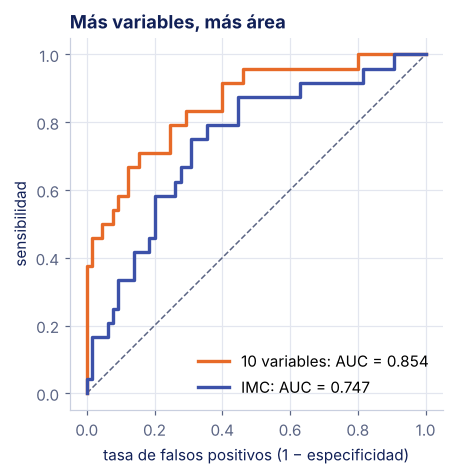

In [29]:
variables = list(diabetes.data.columns)
curva_10 = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf)).fit(entrena[variables], entrena["alta"])
p10 = curva_10.predict_proba(prueba[variables])[:, 1]
fpr10, tpr10, _ = roc_curve(real, p10)

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.plot([0, 1], [0, 1], color=GRIS, linewidth=1, linestyle="--")
ax.plot(fpr10, tpr10, color=NARANJA, linewidth=2.2, drawstyle="steps-post",
        label=f"10 variables: AUC = {roc_auc_score(real, p10):.3f}")
ax.plot(fpr, tpr, color=AZUL_MEDIO, linewidth=2.2, drawstyle="steps-post",
        label=f"IMC: AUC = {roc_auc_score(real, p):.3f}")
ax.set_xlabel("tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("sensibilidad")
ax.set_title("Más variables, más área")
ax.legend(loc="lower right")
ax.set_aspect("equal")
plt.show()

**Lectura.** El AUC pasa de 0.747 a 0.854. A diferencia de la exactitud, no depende del umbral ni de la proporción de clases: mide qué tan bien *ordena* el modelo a los pacientes, antes de decidir dónde cortar.

### Con varias clases

Con tres clases hay una curva por clase, cada una contra el resto, y sus AUC se promedian como las demás métricas. Son los valores de la columna ROC Area de la sección 5. scikit-learn los calcula con `multi_class="ovr"`; su promedio macro coincide con el de la sección 5:

In [30]:
print(f"AUC macro, uno contra el resto: {roc_auc_score(y_prueba, proba, multi_class='ovr', average='macro'):.3f}")

AUC macro, uno contra el resto: 0.780


**Lectura.** La logística ordena bien los vinos de calidad alta (AUC 0.86) y los de calidad baja (0.82), y mal los de calidad media (0.66). Tiene sentido: la clase media queda entre las otras dos, y una sola dirección de probabilidad no la separa de ambas.

---

Lo que sigue es abrir las cajas negras de la sección 6. La próxima sesión empieza con los árboles de decisión: ID3 y C4.5, que en Weka se llama J48.

---

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de Claude (Anthropic) para estructurar el contenido a partir de las diapositivas de la sesión, redactar el texto explicativo y preparar los conjuntos de datos de ejemplo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.

### Referencias

- Domingos, P. (2012). A few useful things to know about machine learning. *Communications of the ACM*, 55(10), 78-87. https://homes.cs.washington.edu/~pedrod/papers/cacm12.pdf
- VanderPlas, J. (2022). *Python Data Science Handbook*, 2a ed. O'Reilly. [Capítulo 39: Hyperparameters and Model Validation](https://jakevdp.github.io/PythonDataScienceHandbook/05.03-hyperparameters-and-model-validation.html)
- Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427-437.
- Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861-874.
- Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. *Proceedings of IJCAI*, 1137-1145.
- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.
- Witten, I. H., Frank, E., Hall, M. A., & Pal, C. J. (2016). *Data Mining: Practical Machine Learning Tools and Techniques*, 4a ed. Morgan Kaufmann. (El libro de Weka.)
- Demšar, J., *et al.* (2013). Orange: Data mining toolbox in Python. *Journal of Machine Learning Research*, 14, 2349-2353.
- [scikit-learn: métricas de clasificación](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics) · [multilabel_confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.multilabel_confusion_matrix.html) · [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)